# 🚀 Working on a Real Project with Python

## (A part of Big Data Analysis)

-------------

## 📊 The Salary Dataset
***
This dataset contains real-world salary information collected from multiple companies across different locations, job roles, and employment types. It is designed to help understand salary trends, pay distribution, and factors influencing compensation in the job market.

The dataset consists of 22,000+ records, making it suitable for exploratory data analysis (EDA), data cleaning, visualization, and business insights generation using Python.

-----------

## 🧠 Questions


1. What does the salary distribution look like?

2. Which job roles have the highest average salary?

3. Which cities offer the highest average salary?

4. Top 5 companies offering the highest average salary?

5. Top 5 companies with salaries reported more than 20 times?

6. Is there a relationship between company rating and salary?

7. Does employment status affect salary?

8. Which job roles are most common?

9. How do salaries vary across locations?

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format','{:.0f}'.format)

In [3]:
df = pd.read_csv('Salary_Dataset_DSL.csv')

In [4]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [5]:
df.shape

(22770, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  str    
 2   Job Title          22770 non-null  str    
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  str    
 6   Employment Status  22770 non-null  str    
 7   Job Roles          22770 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [10]:
df.head(3)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android


In [11]:
df.isnull().sum()

rating               0
company_name         1
job_title            0
salary               0
salaries_reported    0
location             0
employment_status    0
job_roles            0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

rating               0
company_name         0
job_title            0
salary               0
salaries_reported    0
location             0
employment_status    0
job_roles            0
dtype: int64

In [14]:
df

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# 7️⃣ Answering Business Questions

## Q1: Which Job Roles have Highest Average Salary?

In [15]:
df.head(2)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


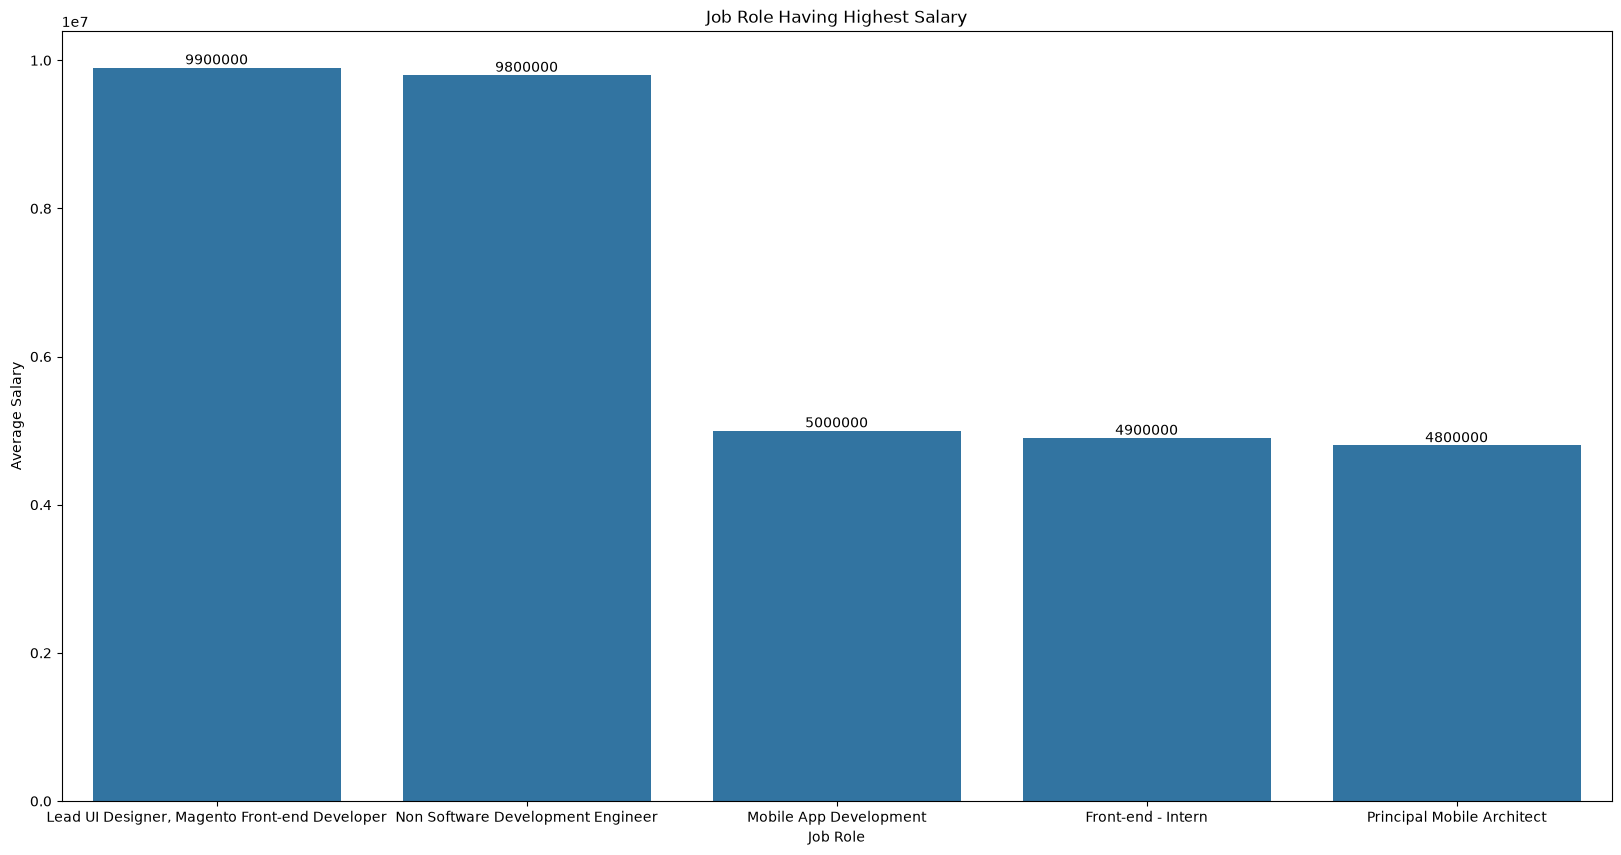

In [16]:
plots = df.groupby('job_title').salary.mean().sort_values(ascending=False).head(5)
plt.figure(figsize=(20,10))
plt.title('Job Role Having Highest Salary')
plt.xlabel('Job Role')
plt.ylabel('Average Salary')
ax = sns.barplot(x = plots.index, y = plots.values)
for i in ax.containers:
    ax.bar_label(i,fmt = '%.0f')
plt.show()

## Q2: Which Cities Offer Highest Average Salary?

In [17]:
df.head(2)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [18]:
df.groupby('location').salary.mean().round(2).sort_values(ascending=False)

location
Mumbai            961180.37
Bangalore         735289.96
Kolkata           710925.57
Pune              690476.31
Hyderabad         679099.16
Madhya Pradesh    677641.91
New Delhi         658756.74
Jaipur            629135.80
Chennai           584559.66
Kerala            553577.48
Name: salary, dtype: float64

## Q3: Name those 5 companies located in 'New Delhi' with Ratings of '5', offering highest & lowest salaries.

In [19]:
df[(df.location == 'New Delhi') & (df.rating == 5)][['company_name','salary','rating']].head()

,company_name,salary,rating
1669,Ango Health,336000,5.0
1723,Neo Fitnes,100000,5.0
1751,Fixdax Technology,300000,5.0
1754,NSPS,216000,5.0
1761,Upper Dauphin Area School District,1000000,5.0


## Q4: Which Job Title has the highest number of salary reported?

In [20]:
df.groupby('job_title').salary.sum().sort_values(ascending = False)

job_title
Software Development Engineer                              1836283760
Software Development Engineer (SDE)                        1429870256
Android Developer                                          1030946784
Front End Developer                                         818055456
Test Engineer                                               659715296
                                                              ...    
Jr Backend Developer - Intern                                   60000
IOS Engineer Contractor                                         36000
Java Software Engineer Contractor                               31680
Senior Software Development Engineer In Test Contractor         27456
Ios App Developer - Intern                                      24000
Name: salary, Length: 1080, dtype: int64

## Q5: Which 10 Companies provide the highest average salary, when at least 20 employees have reported their salaries?

In [21]:
df

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [26]:
df.groupby('company_name').salary.mean().sort_index(ascending=False).head(10)

company_name
‎eNotice Ninja Pluss    400000
​App-Scoop              500000
Órama                  1200000
Ás Formaturas           900000
zekeLabs                 96000
zDistanceLab            180000
zCon Solutions          330000
yo yo honey singh       972000
yes                     500000
yellow.ai               530400
Name: salary, dtype: float64

## Q.6: Check and show the relationship Between Ratings & Salaries.

In [23]:
df.head(2)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


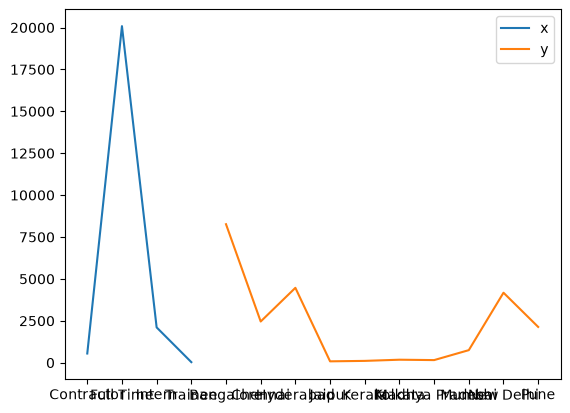

In [64]:
plot = df.groupby('employment_status').location.count()
plot1 = df.groupby('location').location.count()
plt.plot(plot.index, plot.values,label = 'x')
plt.plot(plot1.index, plot1.values,label = 'y')
plt.legend()
plt.show()

## Q.7: Does employment status affect salary?

C:\Users\Admin\AppData\Local\Temp\ipykernel_10668\2769948708.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = plot.index, y = plot.values,palette = ['red','green','blue'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_10668\2769948708.py:5: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x = plot.index, y = plot.values,palette = ['red','green','blue'])


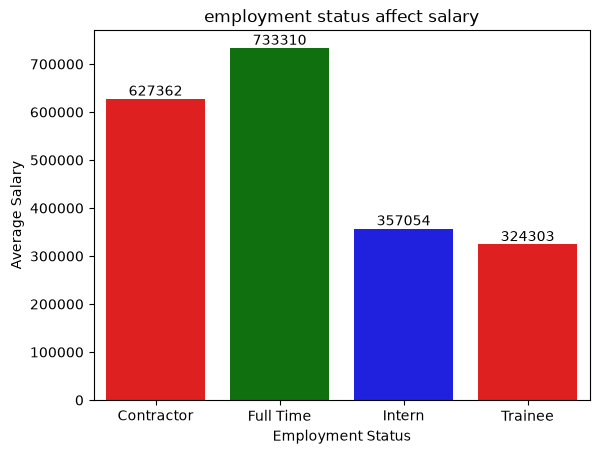

In [34]:
plot = df.groupby('employment_status').salary.mean()
plt.title('employment status affect salary')
plt.xlabel('Employment Status')
plt.ylabel('Average Salary')
ax = sns.barplot(x = plot.index, y = plot.values,palette = ['red','green','blue'])
for i in ax.containers:
    ax.bar_label(i)


## Q.8: Which job roles are most common?

In [35]:
df.head(2)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,4,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


<Axes: xlabel='job_roles'>

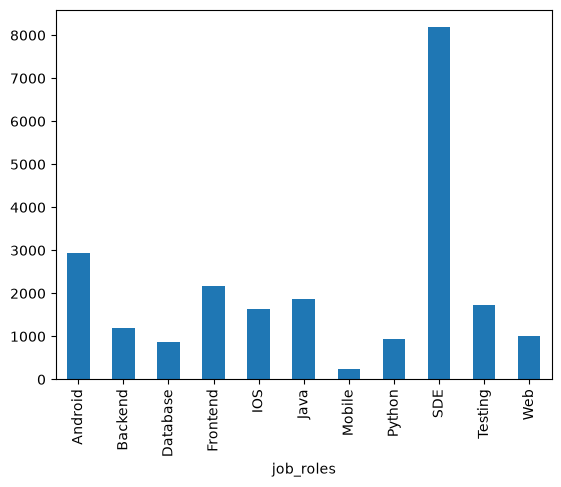

In [41]:
df.groupby('job_roles').job_roles.count().plot(kind = 'bar')

## Q.9: How does average salary change as company rating increases?

In [42]:
df.head(2)

,rating,company_name,job_title,salary,salaries_reported,location,employment_status,job_roles
0,4,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [43]:
df.salary.mean()

np.float64(695365.5760024595)

In [45]:
df.groupby('rating').salary.mean()

rating
1    475578
1   1500000
1    331200
2    241000
2    679500
2    750000
2    330333
2    857600
2    437481
2    465867
2    507814
2    429953
2    612302
2    561175
3    514677
3    545184
3    578295
3    570183
3    508415
3    655836
3    598652
3    686745
3    669226
4    665210
4    784672
4    678324
4    716201
4    598909
4    719883
4    453810
4    669816
4    736495
4    741386
4    743757
4    839434
4    667840
5    696549
5    766247
5    511823
5    653299
5    558320
Name: salary, dtype: float64